# bcCA - cultural dataset

In [1]:
#disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore',category=FutureWarning)
filterwarnings("ignore")

## children dataset

In [2]:
#children dataset
from scientisttools.datasets import cultural
cultural

,Social Class,Theatre,Cinema,Museums,Concerts,Reading,Streaming,Sports,Video Games,Temp Exhibitions,Cultural Podcasts,Festivals,Income,Age,Years Education,Area,Dominant Gender,Dominant Education
Occupation,,,,,,,,,,,,,,,,,,
Farmers,Working,15,40,10,20,35,25,60,20,12,10,18,22000,48,11,Rural,M,Low
Craftsmen,Middle,20,55,15,30,45,40,70,35,18,20,25,28000,45,12,Mixed,M,Medium
Shopkeepers,Middle,18,60,20,35,50,50,65,40,22,25,30,30000,43,13,Urban,M,Medium
Business Owners,Upper,40,70,50,45,80,60,55,25,45,35,50,55000,50,16,Urban,M,High
Senior Executives,Upper,70,85,90,75,120,80,60,30,80,60,75,65000,47,18,Urban,M,High
Intermediate Professions,Middle,45,75,55,60,85,90,70,45,50,55,60,38000,42,15,Mixed,F,Medium
Administrative Employees,Middle,35,65,40,45,75,85,65,50,40,50,45,32000,44,14,Urban,F,Medium
Sales Employees,Working,25,70,30,40,60,95,80,65,28,45,35,26000,39,12,Urban,F,Medium
Skilled Workers,Working,15,55,20,30,45,80,95,70,20,35,30,24000,41,11,Mixed,M,Low


### Instanciation and training

In [3]:
# instanciation
from scientisttools import CA
clf = CA(
    group = 0,
    row_sup = range(20,26),
    col_sup = range(9,12),
    sup_var = range(12,18)
)


### `fit` function

In [4]:
# fit function - with supplementary columns
clf.fit(cultural)

,group,0
,row_sup,"range(20, 26)"
,col_sup,"range(9, 12)"
,sup_var,"range(12, 18)"
,symmetric,True
,ref,None
,iv,None
,ortho,False
,option,'between'
,ncp,5
,tol,1e-07


### `fit_transform` function

In [5]:
#fit_transform - rows coordinates
row_coord = clf.fit_transform(cultural)
row_coord

,Dim1,Dim2,Dim3
Farmers,-0.156031,-0.275978,-0.134051
Craftsmen,-0.171991,-0.142426,-0.113929
Shopkeepers,-0.153525,-0.059098,-0.108278
Business Owners,0.190873,-0.036463,-0.030419
Senior Executives,0.328660,0.031136,0.030091
Intermediate Professions,0.072954,0.031065,-0.002064
Administrative Employees,-0.030697,0.026975,0.004373
Sales Employees,-0.222653,0.018755,0.003527
Skilled Workers,-0.399914,-0.059543,0.038473
Unskilled Workers,-0.551799,-0.040107,0.081090


### `transform` function

In [6]:
#transform function - rows coordinates
#row_coord = clf.transform(clf.call_.X)
#row_coord

## Eigenvalues

In [7]:
#eigen values
from scientisttools import get_eig, fviz_eig
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,0.057085,0.054163,93.990644,93.990644
Dim2,0.002922,0.002194,4.811155,98.801800
Dim3,0.000728,NaN,1.198200,100.000000


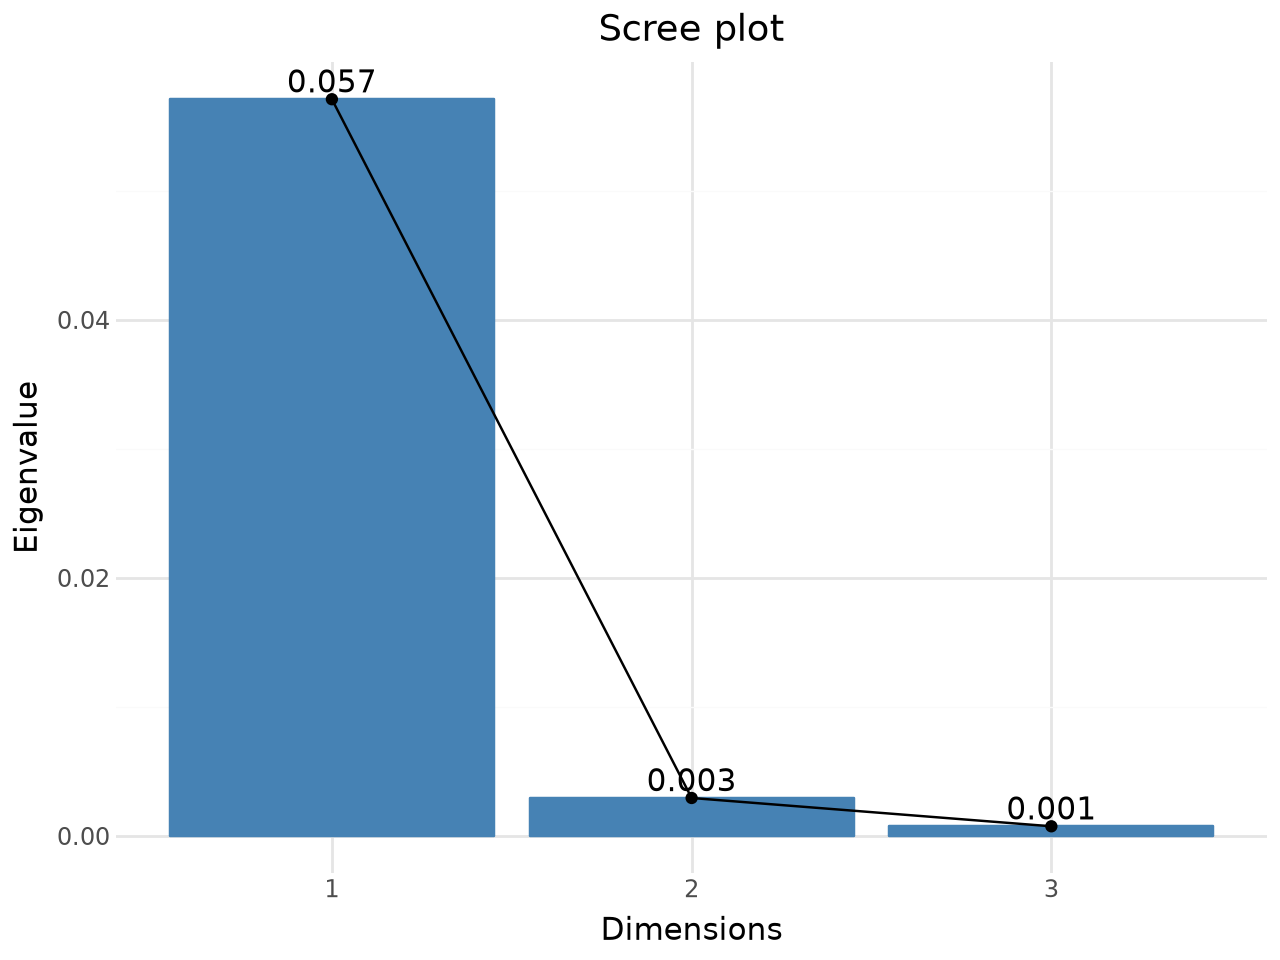

None


In [8]:
# scree plot - eigenvalue
p = fviz_eig(
    obj = clf, 
    choice = "eigenvalue", 
    show_labels = True
)
print(p.show())

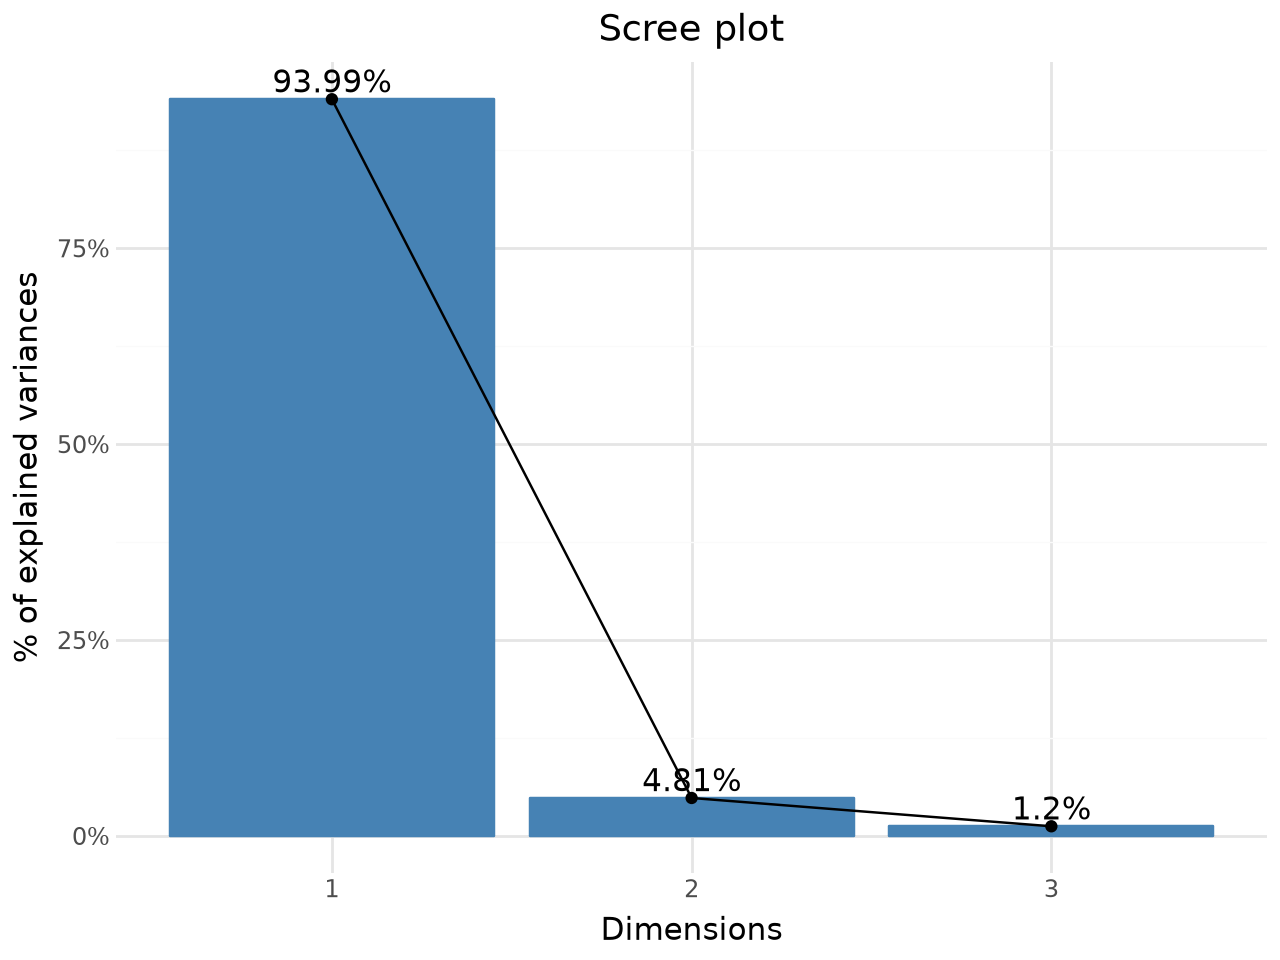

None


In [9]:
# scree plot - proportion of variance
p = fviz_eig(
    obj = clf,
    choice = "proportion",
    show_labels = True
)
print(p.show())

## Rows informations

In [10]:
#rows informations
from scientisttools import get_ca, fviz_ca
row = get_ca(clf,element = "row")
row._fields

('coord', 'cos2', 'dist2')

### Row coordinates

In [11]:
#rows coordinates
row.coord

,Dim1,Dim2,Dim3
Farmers,-0.156031,-0.275978,-0.134051
Craftsmen,-0.171991,-0.142426,-0.113929
Shopkeepers,-0.153525,-0.059098,-0.108278
Business Owners,0.190873,-0.036463,-0.030419
Senior Executives,0.328660,0.031136,0.030091
Intermediate Professions,0.072954,0.031065,-0.002064
Administrative Employees,-0.030697,0.026975,0.004373
Sales Employees,-0.222653,0.018755,0.003527
Skilled Workers,-0.399914,-0.059543,0.038473
Unskilled Workers,-0.551799,-0.040107,0.081090


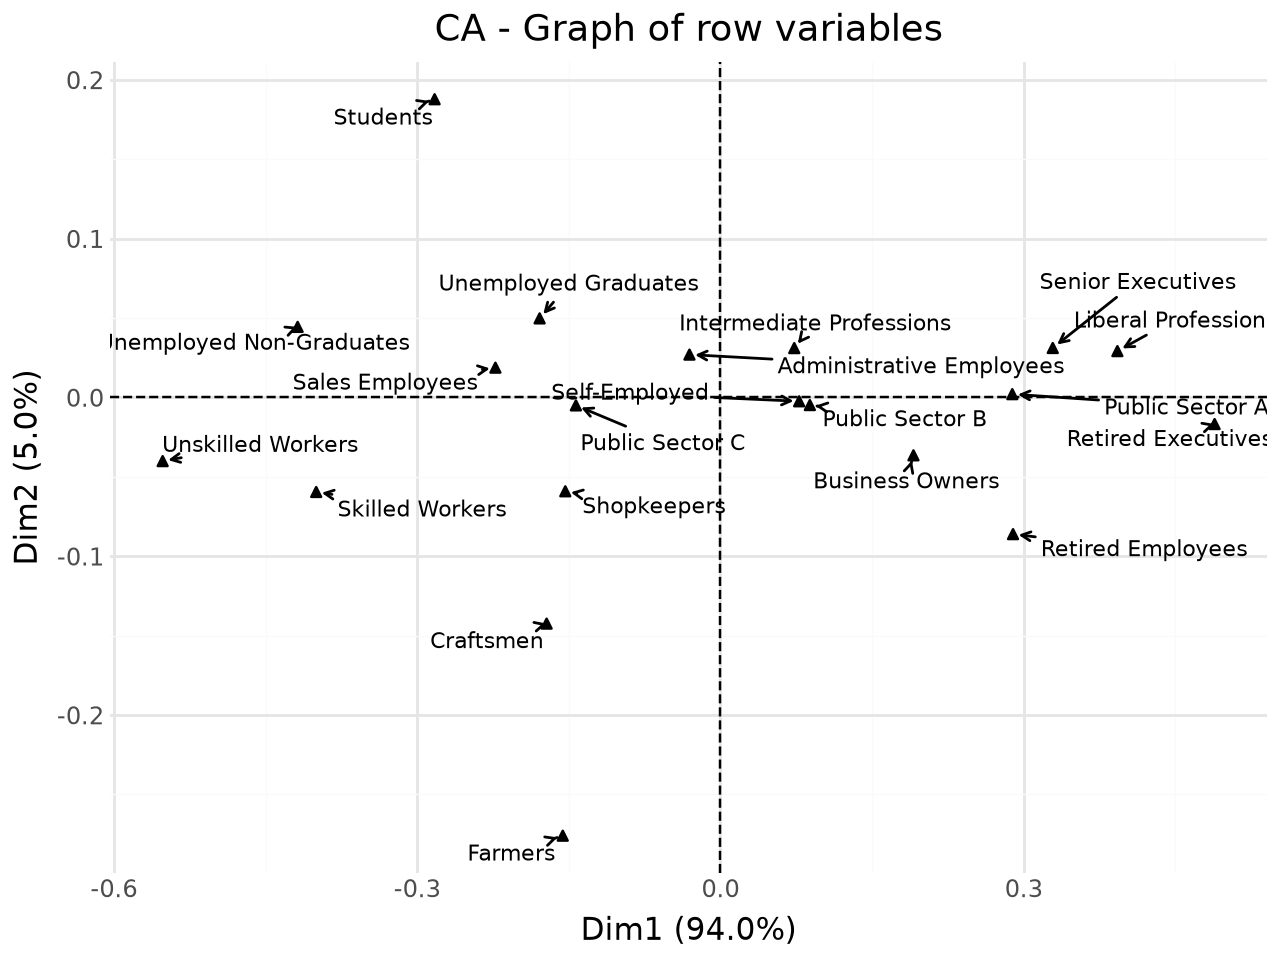

None


In [12]:
# row points
from plotnine import ggplot
from scientisttools import add_scatter, set_axis
p = add_scatter(
    p=ggplot(),
    data=clf.row_.coord,
    color = "black",
    repel=True
)
p = set_axis(
    p=p,
    obj=clf,
    title = "CA - Graph of row variables"
)
print(p.show())

### Row cos2

In [13]:
#rows cos2
row.cos2

,Dim1,Dim2,Dim3
Farmers,0.170509,0.533422,0.125852
Craftsmen,0.380555,0.260968,0.166983
Shopkeepers,0.552177,0.081822,0.274665
Business Owners,0.922020,0.033648,0.023418
Senior Executives,0.971739,0.008721,0.008146
Intermediate Professions,0.589126,0.106821,0.000472
Administrative Employees,0.147794,0.114130,0.002999
Sales Employees,0.920980,0.006535,0.000231
Skilled Workers,0.964476,0.021381,0.008926
Unskilled Workers,0.955012,0.005045,0.020624


### Rows dist2

In [14]:
#rows additionals informations
row.dist2.to_frame()

,Sq. Dist.
Farmers,0.142784
Craftsmen,0.077731
Shopkeepers,0.042685
Business Owners,0.039514
Senior Executives,0.111159
Intermediate Professions,0.009034
Administrative Employees,0.006376
Sales Employees,0.053828
Skilled Workers,0.165822
Unskilled Workers,0.318825


## Columns informations

In [15]:
#columns informations
col = get_ca(clf,element = "col")
col._fields

('coord', 'cos2', 'contrib', 'infos')

### Columns coordinates

In [16]:
#columns coordinates
col.coord

,Dim1,Dim2,Dim3
Theatre,0.308741,0.010066,0.022824
Cinema,0.014125,-0.002724,-0.031702
Museums,0.348591,0.008827,0.053118
Concerts,0.122572,0.074484,-0.039419
Reading,0.188040,-0.031784,-0.015327
Streaming,-0.137353,0.019243,0.008723
Sports,-0.231616,-0.098845,0.004069
Video Games,-0.438604,0.079276,0.022176


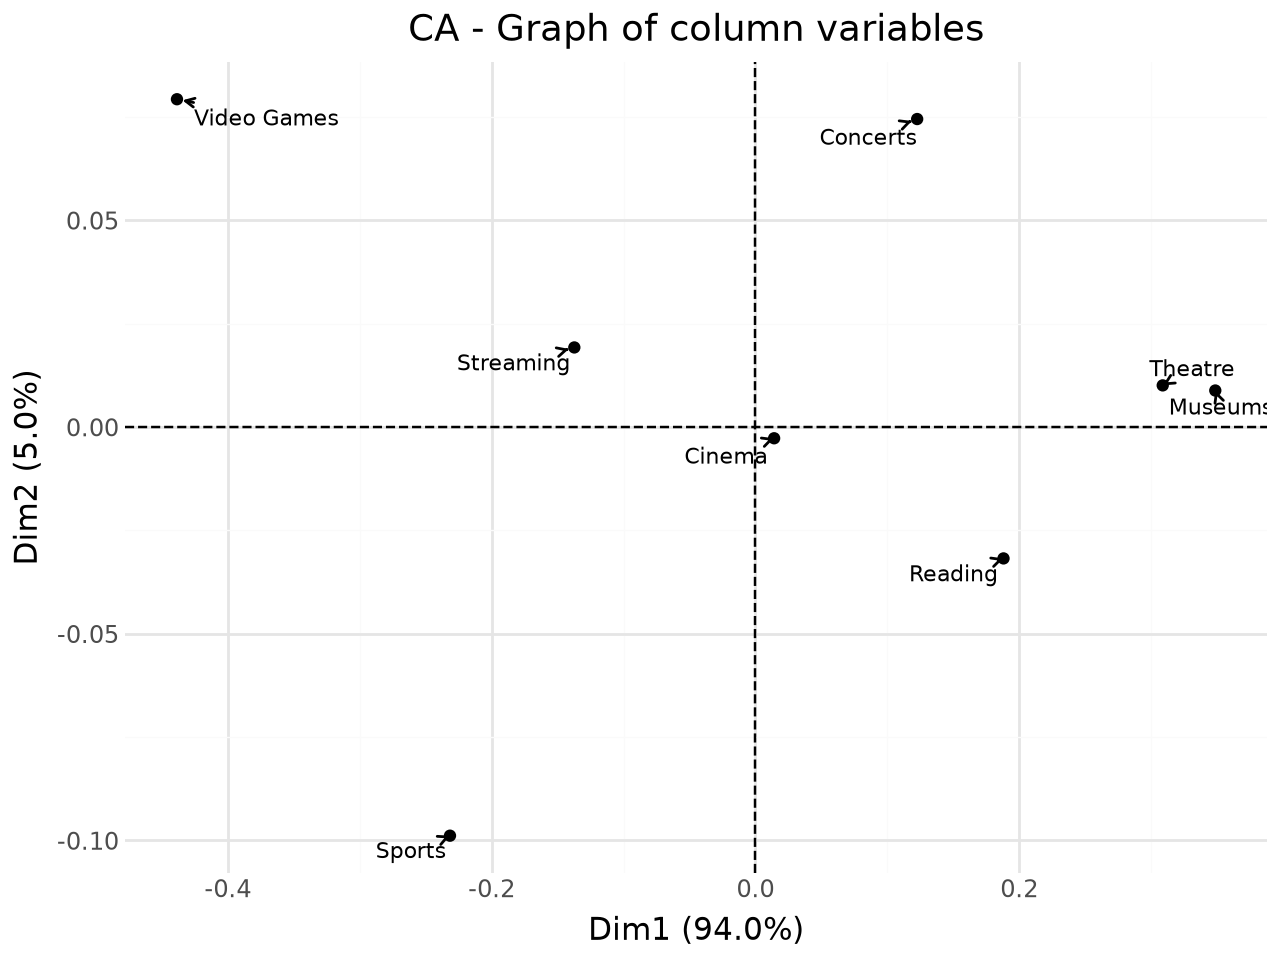

None


In [17]:
# column points
p = fviz_ca(
    obj = clf,
    choice = "col",
    col_sup = False,
    repel = True
)
print(p.show())

### Columns contributions

In [18]:
#columns contributions
col.contrib

,Dim1,Dim2,Dim3
Theatre,12.594228,0.261525,5.398867
Cinema,0.052488,0.038149,20.739437
Museums,20.874109,0.261504,38.019566
Concerts,2.684040,19.362819,21.775615
Reading,9.857300,5.501909,5.137179
Streaming,5.351928,2.052129,1.693217
Sports,14.217935,50.587759,0.344171
Video Games,34.367971,21.934206,6.891948


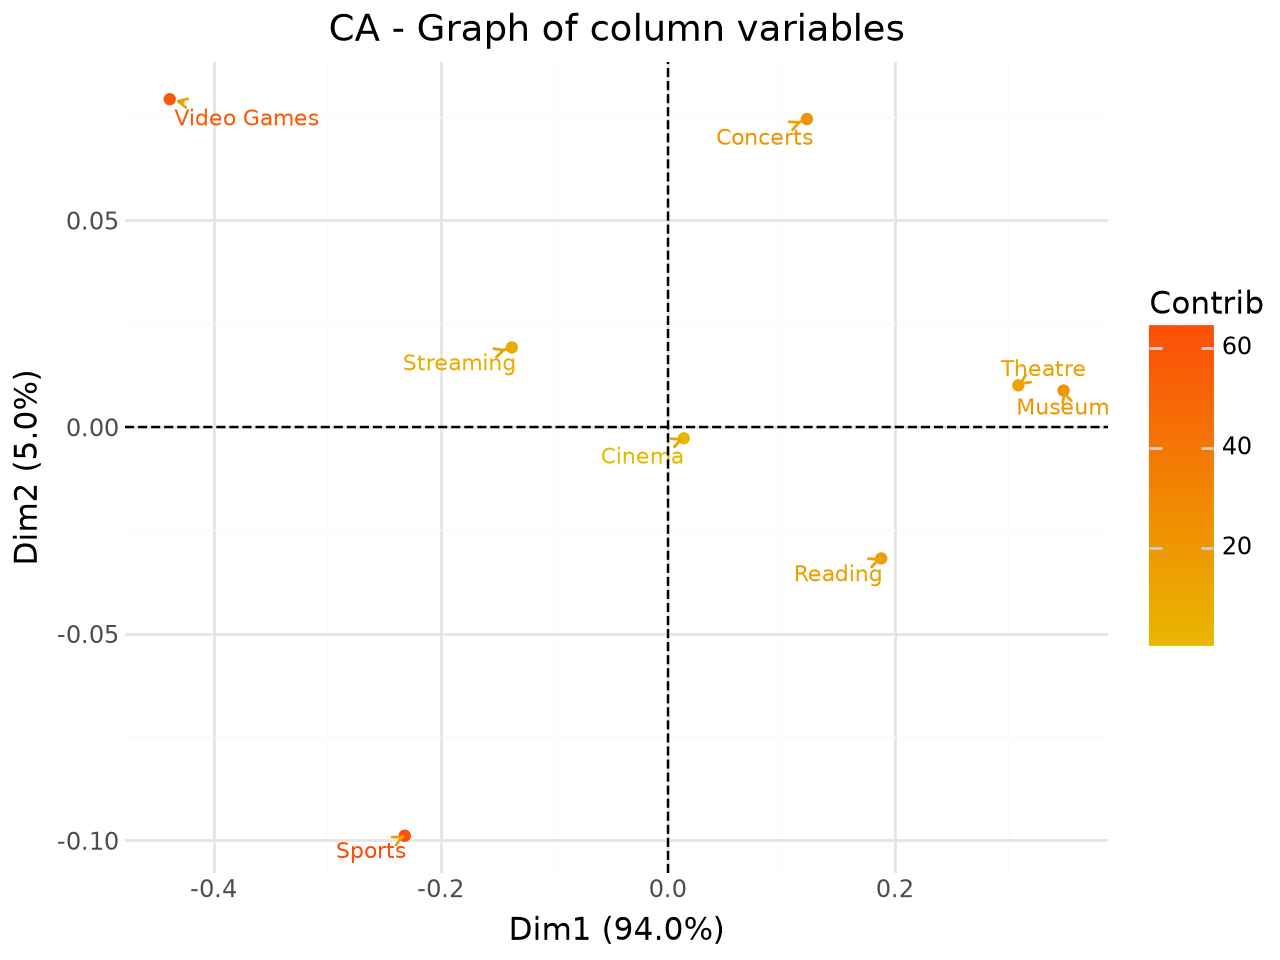

None


In [19]:
# column points colored by contrib
p = fviz_ca(
    obj = clf, 
    choice = "col", 
    col_col = "contrib",
    col_sup = False,
    repel = True
)
print(p.show())

### Columns cos2

In [20]:
#columns cos2
col.cos2

,Dim1,Dim2,Dim3
Theatre,0.993515,0.001056,0.005429
Cinema,0.164629,0.006125,0.829246
Museums,0.976696,0.000626,0.022678
Concerts,0.679027,0.250744,0.070228
Reading,0.965983,0.027599,0.006418
Streaming,0.976886,0.019174,0.003940
Sports,0.845712,0.154027,0.000261
Video Games,0.965973,0.031557,0.002469


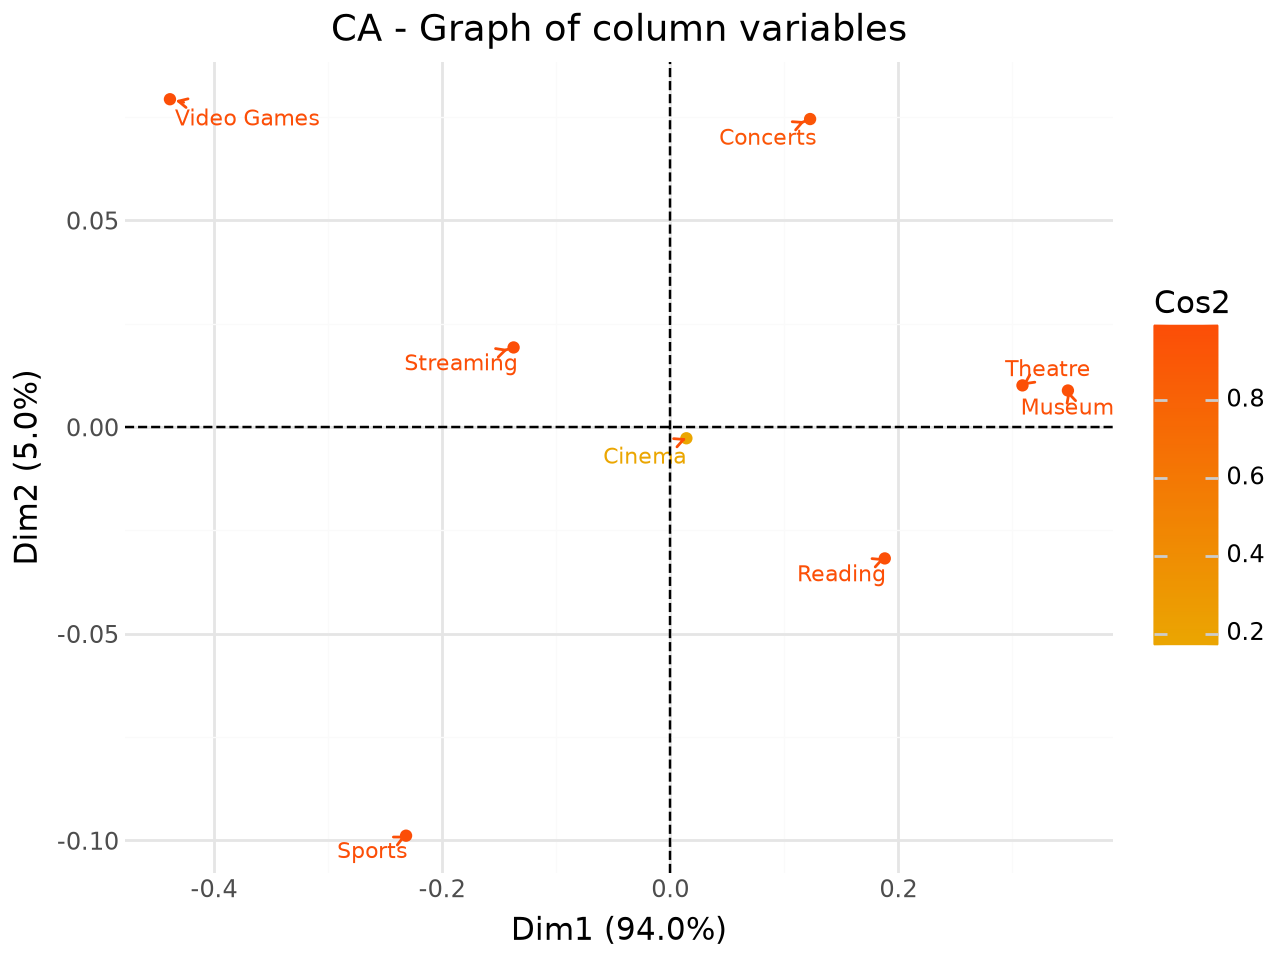

None


In [21]:
# column points colored by cos2
p = fviz_ca(
    obj = clf,
    choice = "col",
    col_col = "cos2",
    col_sup = False,
    repel = True
)
print(p.show())

### Columns additionals informations

In [22]:
#columns additionals informations
col.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
Theatre,0.075423,0.095943,0.007236,11.914667
Cinema,0.150174,0.001212,0.000182,0.299670
Museums,0.098061,0.124415,0.012200,20.087842
Concerts,0.101984,0.022126,0.002256,3.715237
Reading,0.159139,0.036604,0.005825,9.591199
Streaming,0.161941,0.019312,0.003127,5.149331
Sports,0.151294,0.063433,0.009597,15.801508
Video Games,0.101984,0.199150,0.020310,33.440546


## Groups informations

In [23]:
# groups informations
group = clf.group_
group._fields

('coord', 'cos2', 'contrib', 'infos')

### Groups coordinates

In [24]:
# groups coordinates
group.coord

,Dim1,Dim2,Dim3
Middle,0.034919,-0.024003,-0.036482
Student,-0.282805,0.187784,-0.014272
Upper,0.266731,0.011507,0.021316
Working,-0.320747,-0.033708,0.021557


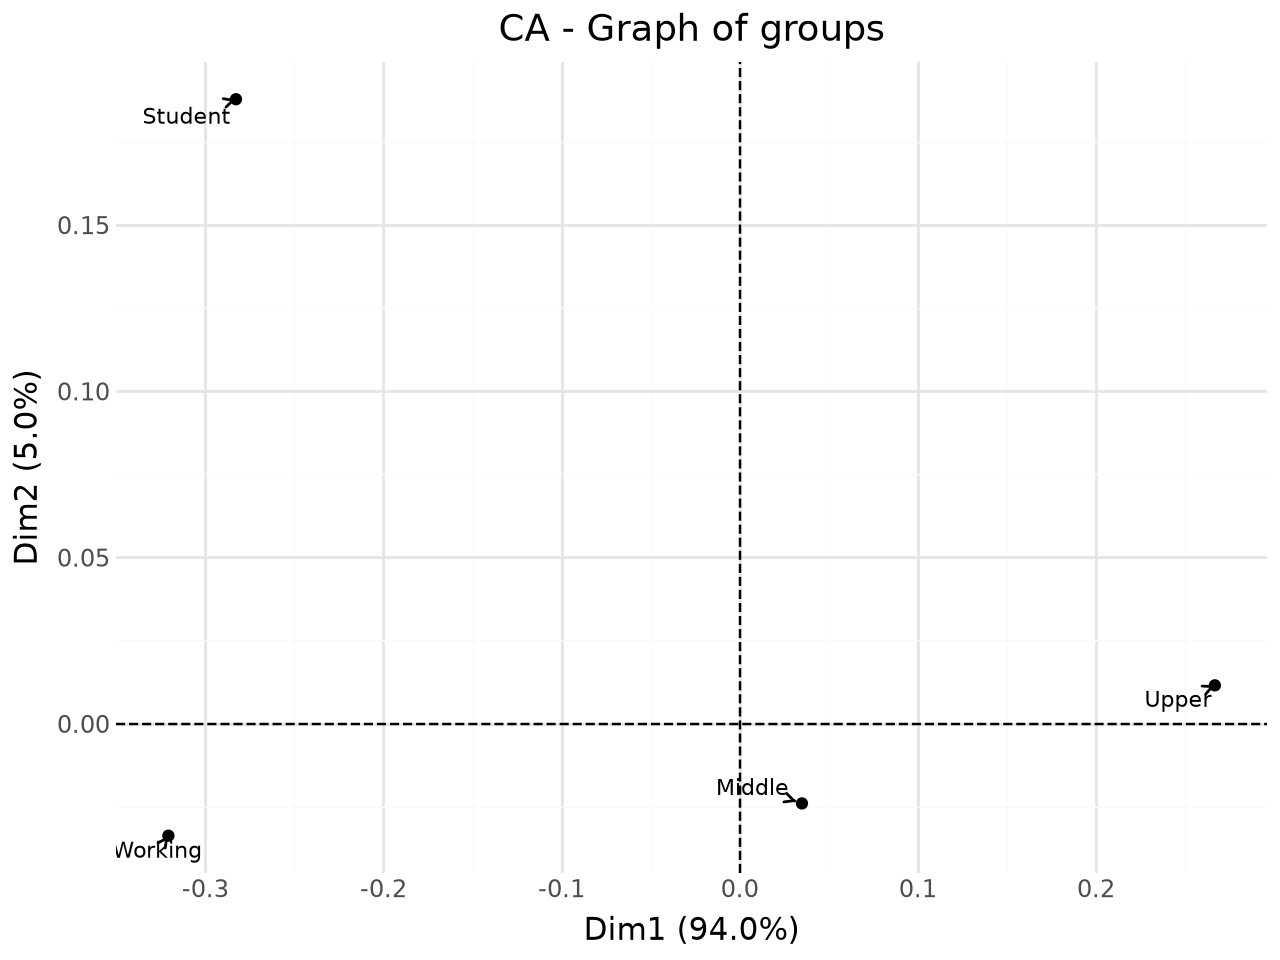

None


In [25]:
# groups points
from scientisttools import fviz_scatter
p = fviz_scatter(
    obj = clf,
    choice = "group",
    repel = True
)
p = set_axis(
    p=p,
    obj=clf,
    title = "CA - Graph of groups"
)
print(p.show())

### Groups contributions

In [26]:
# groups contributions
group.contrib

,Dim1,Dim2,Dim3
Middle,0.700898,6.469755,60.015271
Student,9.499398,81.822515,1.897856
Upper,42.740018,1.553909,21.412674
Working,47.059686,10.153821,16.674199


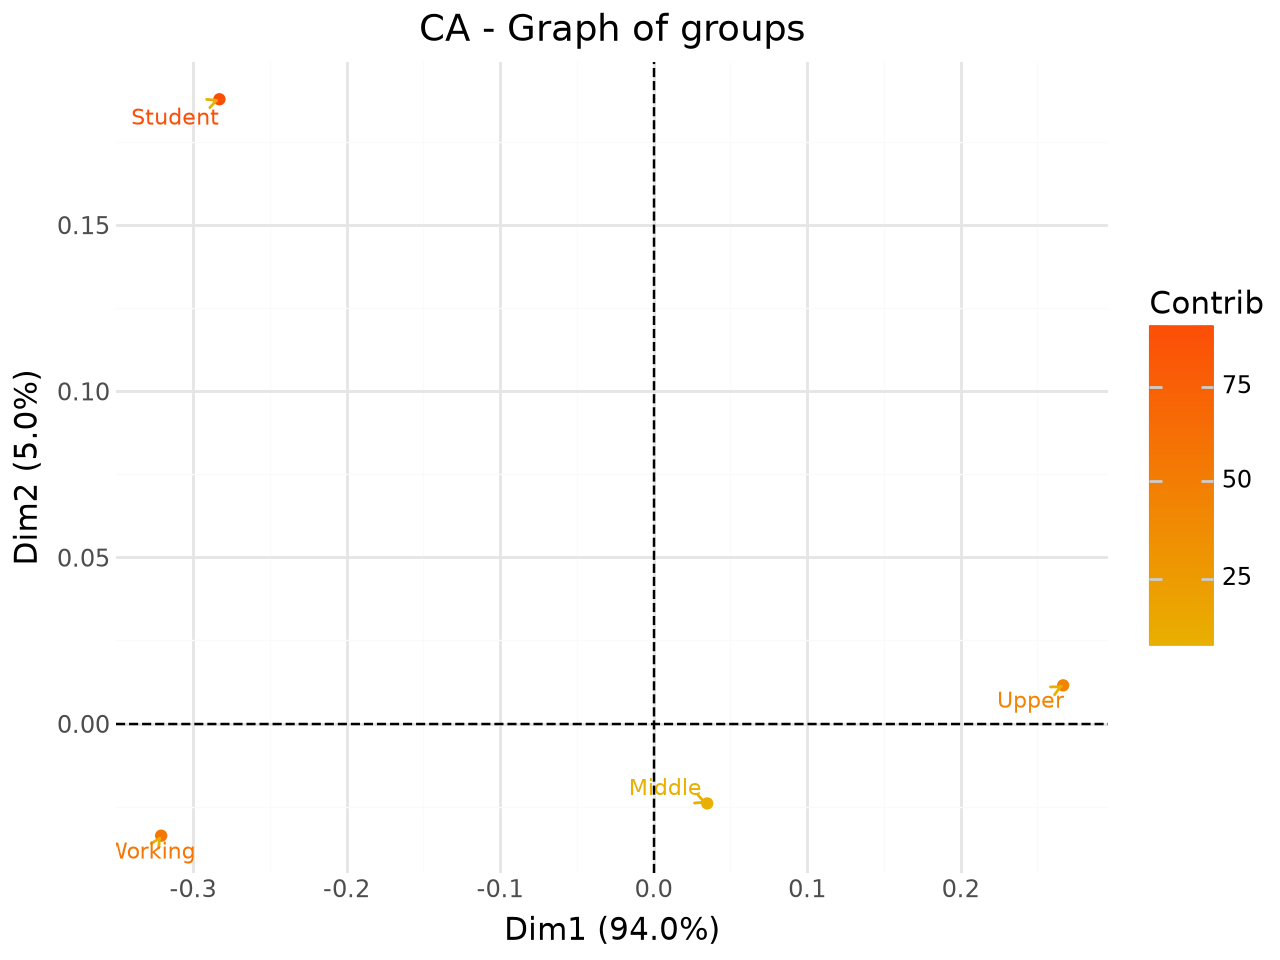

None


In [27]:
# groups points colored by contrib
p = fviz_scatter(
    obj = clf,
    choice = "group",
    color = "contrib",
    repel = True
)
p = set_axis(
    p=p,
    obj=clf,
    title = "CA - Graph of groups"
)
print(p.show())

### Groups cos2

In [28]:
# groups cos2
group.cos2

,Dim1,Dim2,Dim3
Middle,0.390006,0.184276,0.425719
Student,0.692785,0.305450,0.001764
Upper,0.991820,0.001846,0.006335
Working,0.984677,0.010875,0.004448


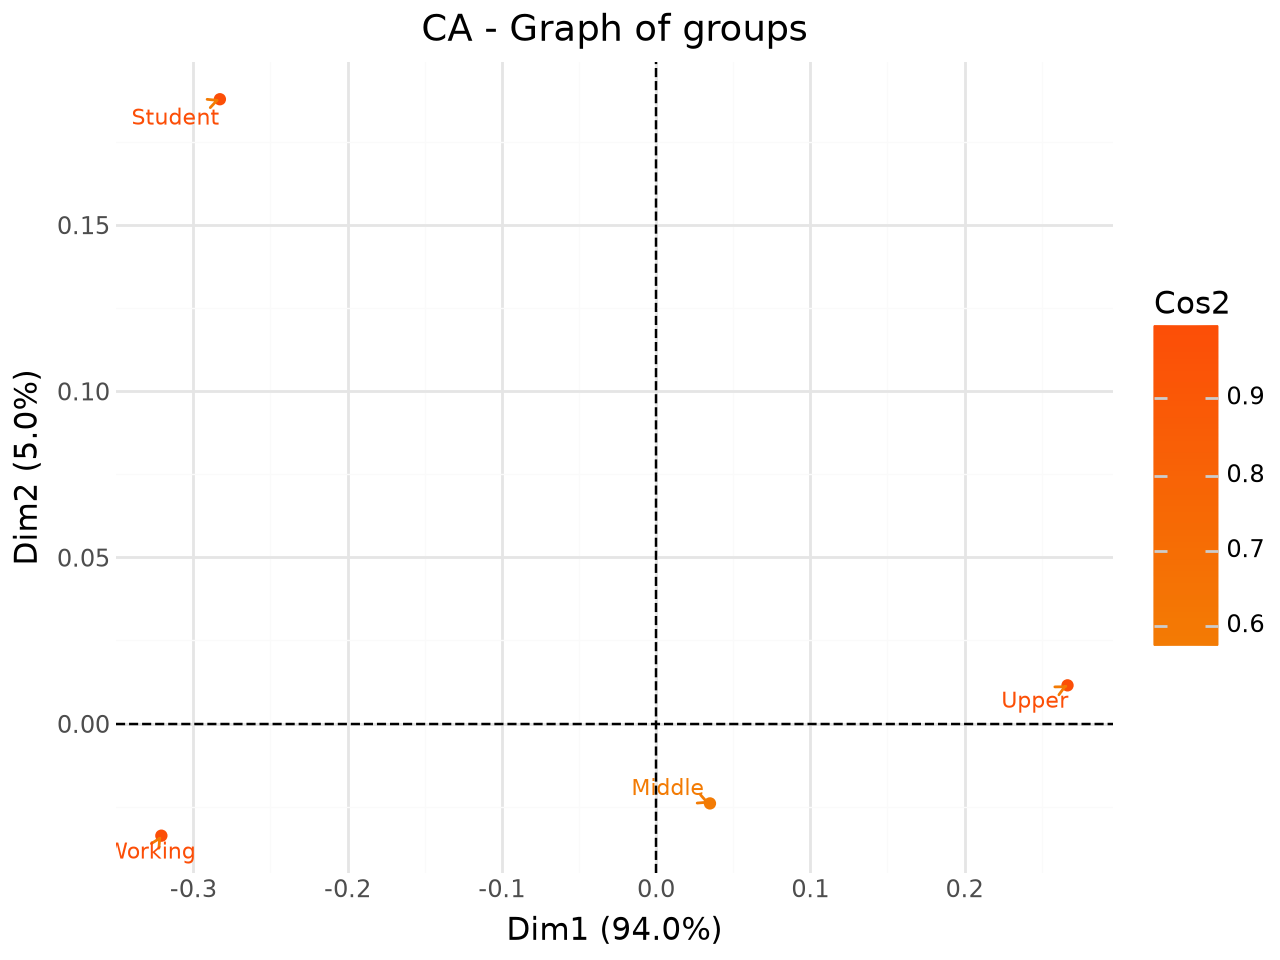

None


In [29]:
# groups points colored by cos2
p = fviz_scatter(
    obj = clf,
    choice = "group",
    color = "cos2",
    repel = True
)
p = set_axis(
    p=p,
    obj=clf,
    title = "CA - Graph of groups"
)
print(p.show())

### Groups additionals informations

In [30]:
# groups additionals informations
group.infos

,Weight,Sq. Dist.,Inertia,Inertia (%)
Middle,0.328141,0.003126,0.001026,1.689152
Student,0.067802,0.115445,0.007827,12.887894
Upper,0.342934,0.071732,0.024599,40.502946
Working,0.261123,0.104480,0.027282,44.920008


## Supplementary rows informations

In [31]:
#supplementary rows informations
row_sup = clf.row_sup_
row_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary rows coordinates

In [32]:
#supplementary rows coordinates
row_sup.coord

,Dim1,Dim2,Dim3
Military,-0.208597,-0.166936,-0.019524
Clergy,0.647708,-0.186016,0.181387
Homemakers,-0.078245,-0.011079,0.007144
Micro-Entrepreneurs,-0.026872,0.061437,-0.033268
Apprentices,-0.521306,0.077785,0.016859
Artists,0.481401,0.106215,0.109129


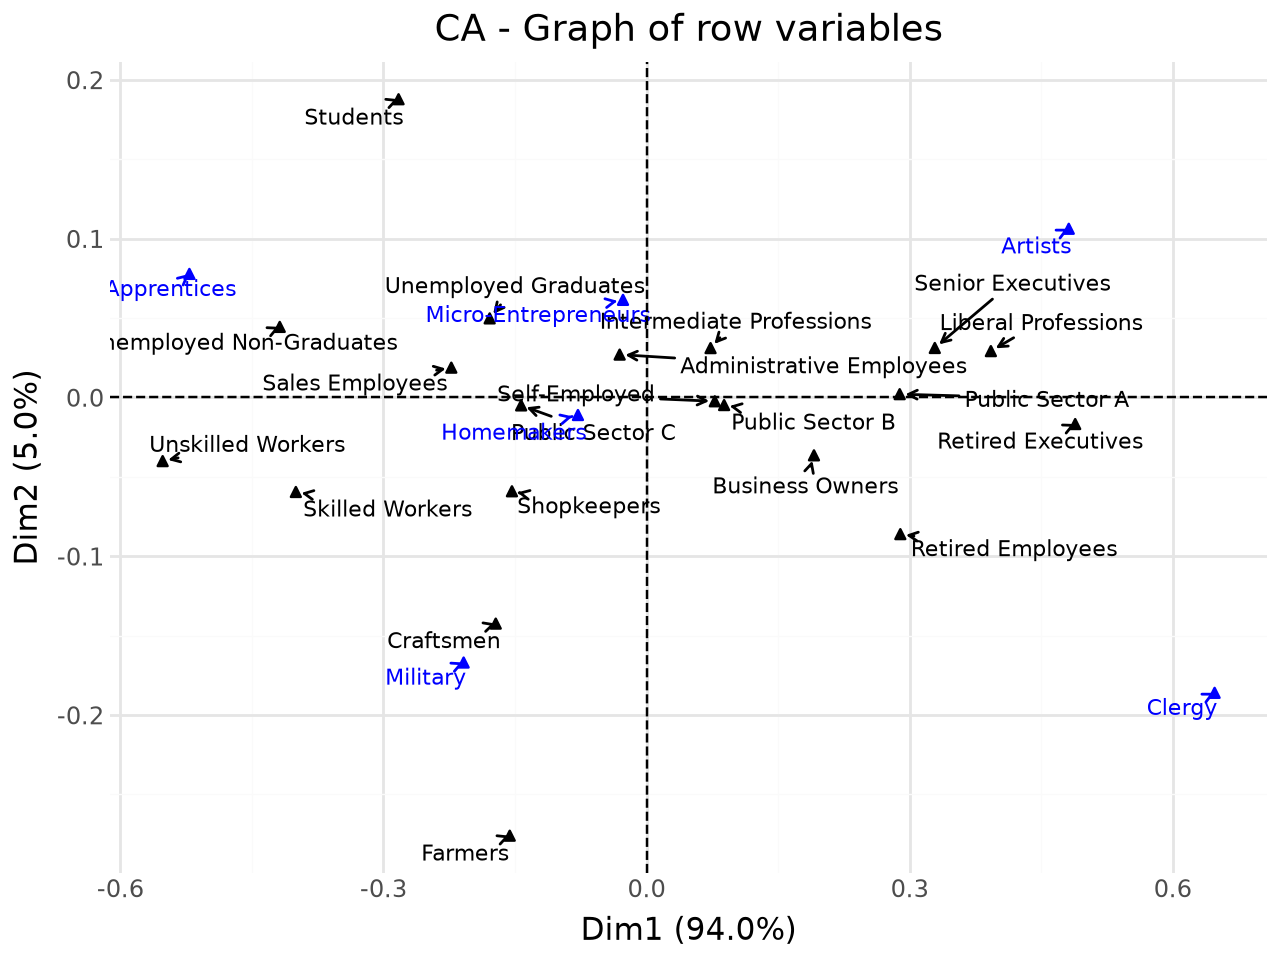

None


In [33]:
# rows points
p = add_scatter(
    p=ggplot(),
    data=clf.row_.coord,
    color = "black",
    repel=True
)
# supplementary row points
p = add_scatter(
    p=p,
    data=clf.row_sup_.coord,
    repel=True
)
p = set_axis(
    p=p,
    obj=clf,
    title = "CA - Graph of row variables"
)
print(p.show())

#### Supplementary rows cos2

In [34]:
# supplementary rows cos2
row_sup.cos2

,Dim1,Dim2,Dim3
Military,0.563614,0.360967,0.004937
Clergy,0.682570,0.056298,0.053530
Homemakers,0.170634,0.003421,0.001422
Micro-Entrepreneurs,0.088934,0.464867,0.136305
Apprentices,0.960800,0.021391,0.001005
Artists,0.798650,0.038879,0.041041


#### Supplementary rows dist2

In [35]:
# supplementary rows dist2
row_sup.dist2.to_frame()

,Sq. Dist.
Military,0.077203
Clergy,0.614627
Homemakers,0.035879
Micro-Entrepreneurs,0.008120
Apprentices,0.282848
Artists,0.290174


## Supplementary columns informations

In [36]:
# supplementary columns informations
col_sup = clf.col_sup_
col_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary columns coordinates

In [37]:
#supplementary columns coordinates
col_sup.coord

,Dim1,Dim2,Dim3
Temp Exhibitions,0.305371,0.048820,0.019716
Cultural Podcasts,0.032800,0.068857,-0.000195
Festivals,0.135496,0.124747,-0.023288


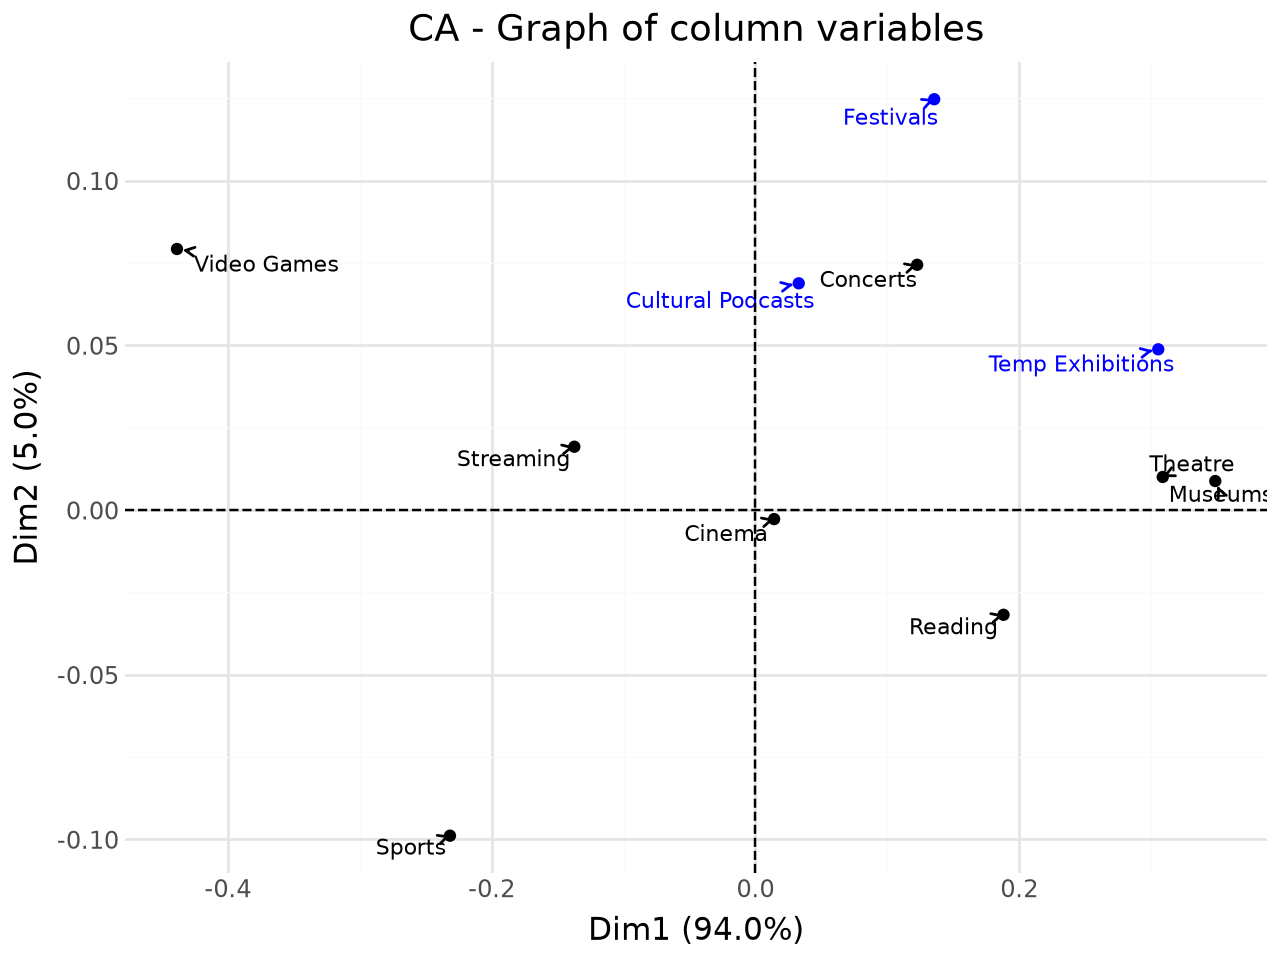

None


In [38]:
# column points
p = fviz_ca(
    obj = clf,
    choice = "col",
    col_sup = True,
    repel = True
)
print(p.show())

### Supplementary columns cos2

In [39]:
# supplementary columns cos2
col_sup.cos2

,Dim1,Dim2,Dim3
Temp Exhibitions,0.971131,0.024821,0.004048
Cultural Podcasts,0.184944,0.815050,0.000007
Festivals,0.532716,0.451547,0.015737


### Supplementary columns dist2

In [40]:
# supplementary columns dist2
col_sup.dist2.to_frame()

,Sq. Dist.
Temp Exhibitions,0.096023
Cultural Podcasts,0.005817
Festivals,0.034463


## Supplementary quantitative variables informations

In [41]:
# supplementary quantitative variables informations
quanti_var_sup = clf.quanti_var_sup_
quanti_var_sup._fields

('coord', 'cos2', 'dist2')

### Supplementary quantitative variables coordinates

In [42]:
# supplementary quantitative variables coordinates
quanti_var_sup.coord

,Dim1,Dim2,Dim3
Income,0.753172,-0.080001,0.231129
Age,0.498056,-0.449319,0.025037
Years Education,0.863892,0.270243,0.158713


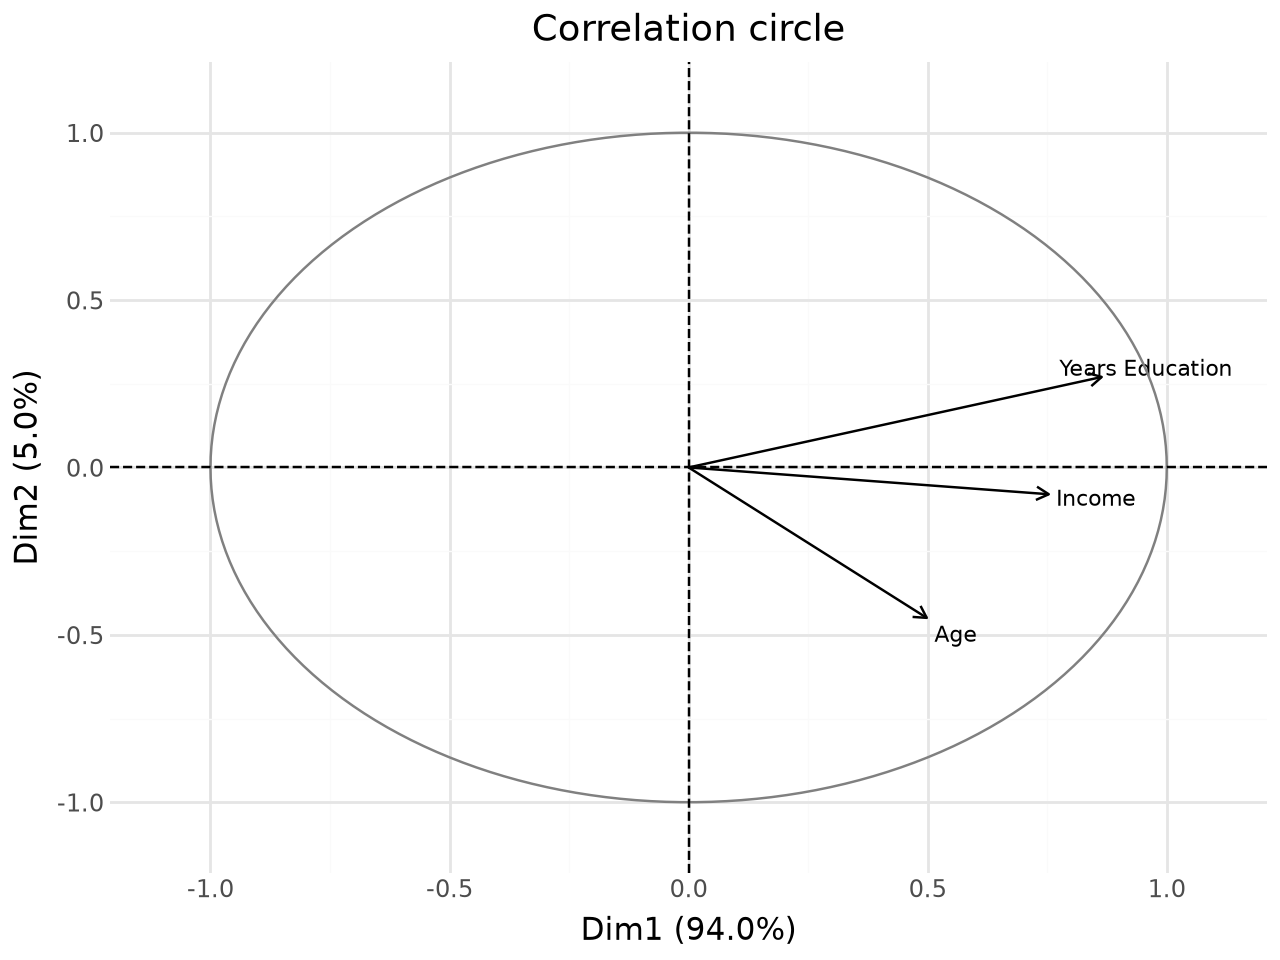

None


In [43]:
# graph of variables (=correlation circle)
from scientisttools import fviz_corcircle
p = fviz_corcircle(clf,repel=True)
print(p.show())

### Supplementary quantitative variables cos2

In [44]:
#supplementary quantitative variables cos2
quanti_var_sup.cos2

,Dim1,Dim2,Dim3
Income,0.904605,0.010206,0.085188
Age,0.550542,0.448067,0.001391
Years Education,0.883697,0.086476,0.029827


## Supplementary levels informations

In [45]:
# supplementary levels informations
levels_sup = clf.levels_sup_
levels_sup._fields

('coord', 'cos2', 'dist2', 'vtest')

### Supplementary levels coordinates

In [46]:
#supplementary levels coordinates
levels_sup.coord

,Dim1,Dim2,Dim3
Mixed,0.001689,-0.034301,-0.022228
Rural,-0.408173,-0.125706,0.003015
Urban,0.043168,0.028642,0.009473
F,0.027640,0.031517,0.004459
M,-0.033819,-0.038562,-0.005456
High,0.266731,0.011507,0.021316
Low,-0.408565,-0.059879,0.032588
Medium,-0.016920,-0.016621,-0.026803
Ongoing,-0.282805,0.187784,-0.014272


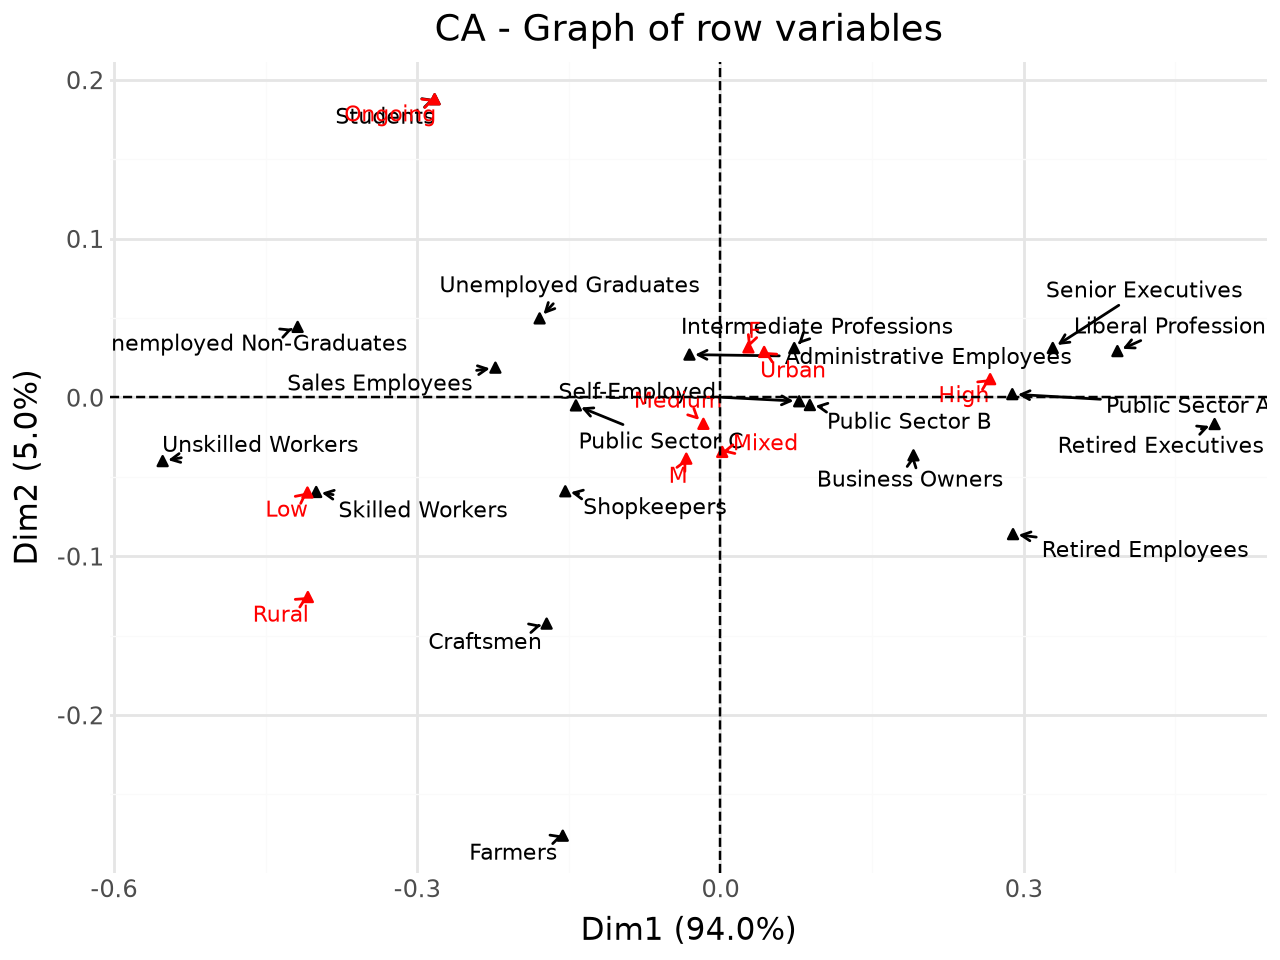

None


In [47]:
# rows points
p = add_scatter(
    p=ggplot(),
    data=clf.row_.coord,
    color = "black",
    repel=True
)
# supplementary levels points
p = add_scatter(
    p = p,
    data = levels_sup.coord,
    color = "red",
    repel = True
)
p = set_axis(
    p=p,
    obj=clf,
    title = "CA - Graph of row variables"
)
print(p.show())

### Supplementary levels vtest

In [48]:
#supplementary levels vtest
levels_sup.vtest

,Dim1,Dim2,Dim3
Mixed,0.100616,-2.043840,-1.324477
Rural,-10.535475,-3.244624,0.077816
Urban,5.506504,3.653533,1.208327
F,2.887906,3.292970,0.465930
M,-2.887906,-3.292970,-0.465930
High,18.201405,0.785204,1.454606
Low,-16.788762,-2.460561,1.339104
Medium,-1.388438,-1.363932,-2.199452
Ongoing,-7.204206,4.783622,-0.363573


### Supplementary levels dist2

In [49]:
#supplementary levels dist2
levels_sup.dist2.to_frame()

,Sq. Dist.
Mixed,0.001760
Rural,0.192267
Urban,0.002953
F,0.002418
M,0.003620
High,0.071732
Low,0.172809
Medium,0.001450
Ongoing,0.115445


### Supplementary levels cos2

In [50]:
#supplementary levels cos2
levels_sup.cos2

,Dim1,Dim2,Dim3
Mixed,0.001620,0.668354,0.280673
Rural,0.866532,0.082187,0.000047
Urban,0.631135,0.277841,0.030391
F,0.315980,0.410837,0.008225
M,0.315980,0.410837,0.008225
High,0.991820,0.001846,0.006335
Low,0.965953,0.020749,0.006145
Medium,0.197414,0.190506,0.495396
Ongoing,0.692785,0.305450,0.001764


## Supplementary qualitative variables

In [51]:
# supplementary qualitative variables
quali_var_sup = clf.quali_var_sup_
quali_var_sup._fields

('coord',)

### Supplementary qualitative variables coordinates

In [52]:
#supplementary qualitative variables coordinates
quali_var_sup.coord

,Dim1,Dim2,Dim3
Area,0.154022,0.316091,0.079139
Dominant Gender,0.011265,0.195734,0.009665
Dominant Education,0.680992,0.503386,0.257248


## Others elements

### Summary

In [53]:
# summary informations
from scientisttools import summary
summary(clf)

                     Correspondence Analysis - Results                     

Importance of components:
      Eigenvalue  Difference  Proportion (%)  Cumulative (%)
Dim1      0.0571      0.0542         93.9906         93.9906
Dim2      0.0029      0.0022          4.8112         98.8018
Dim3      0.0007         NaN          1.1982        100.0000

Groups:
           Dim1    cos2      ctr    Dim2    cos2      ctr    Dim3    cos2  \
Middle   0.0349  0.3900   0.7009 -0.0240  0.1843   6.4698 -0.0365  0.4257   
Student -0.2828  0.6928   9.4994  0.1878  0.3055  81.8225 -0.0143  0.0018   
Upper    0.2667  0.9918  42.7400  0.0115  0.0018   1.5539  0.0213  0.0063   
Working -0.3207  0.9847  47.0597 -0.0337  0.0109  10.1538  0.0216  0.0044   

             ctr  
Middle   60.0153  
Student   1.8979  
Upper    21.4127  
Working  16.6742  

Rows (the 10 first):
                            Dim1    cos2    Dim2    cos2    Dim3    cos2
Farmers                  -0.1560  0.1705 -0.2760  0.5334 -0.1341  0.